# Flausch detection: Task 2 span classification -- Train BERT Token Classifier  

*Task* 2 of GermEval@Konvens 2025 Shared task [Candy speech detection (Flausch-Erkennung)](https://yuliacl.github.io/GermEval2025-Flausch-Erkennung/)

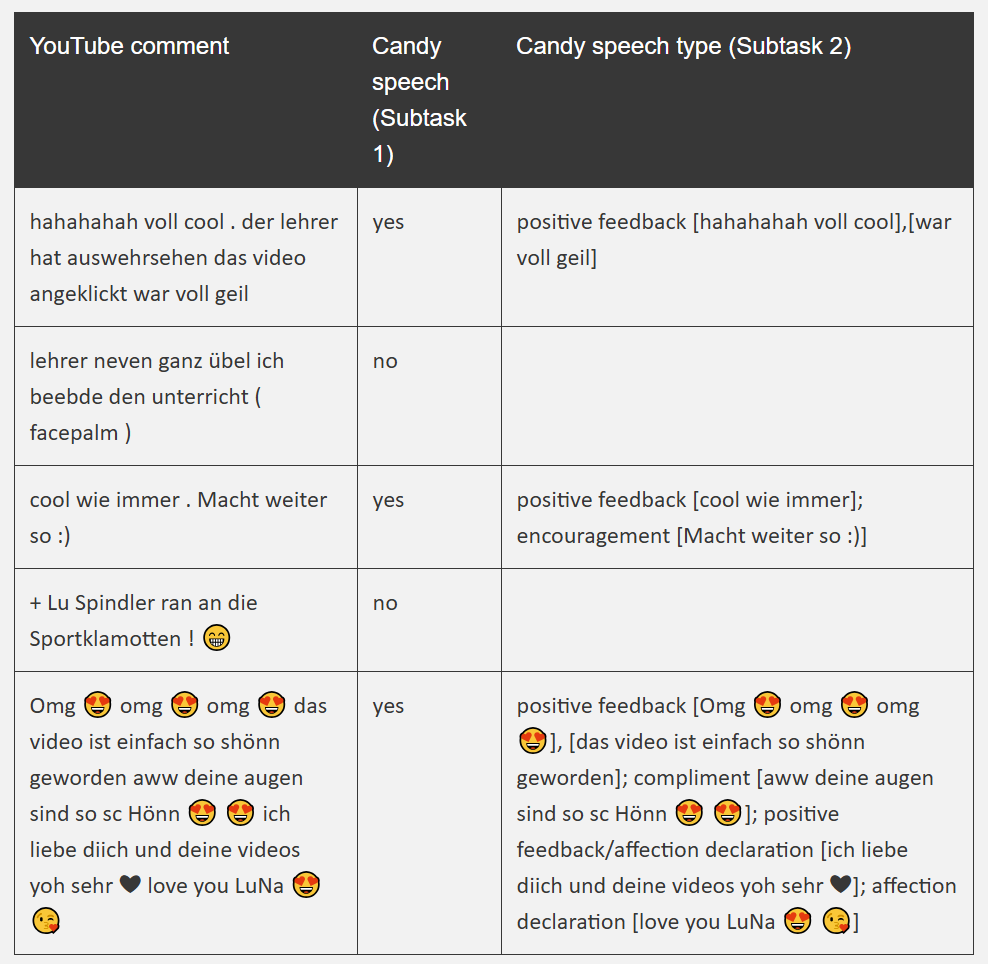


### Dataset preparation

In [1]:

import numpy as np
import pandas as pd

# 1. Base path pointing to the raw GitHub user content
base_path = (
    "https://raw.githubusercontent.com/WiebkePetersen/GermevalFlausch/main/Input/Data/"
)

# 2. Load Task 1 data (Inside the 'train' folder)
# Added typ='frame' to ensure pandas parses it as a DataFrame cleanly
data = pd.read_json(base_path + "train/train_task1.json", typ="frame")
data = data[
    [
        "document",
        "comment_id",
        "comment",
        "flausch",
        "spans",
        "span_pairs",
        "types",
        "id",
    ]
].copy()

# 3. Load Task 2 data
data2 = pd.read_json(base_path + "train/train_task2.json", typ="frame")
data2 = data2[
    [
        "document",
        "comment_id",
        "type",
        "start",
        "end",
        "comment",
        "flausch",
        "span",
        "id",
    ]
].copy()

In [2]:
data.iloc[30:35]

,document,comment_id,comment,flausch,spans,span_pairs,types,id
27154,NDY-208,8844,Ich frühstücke nie morgens wenn wir Schule hab...,no,[],[],[],NDY-208_8844
31242,NDY-247,300,Ich finde dich echt Sympatisch ;) ... Bist ech...,yes,"[Ich finde dich echt Sympatisch ;), Bist echt ...","[[0, 33], [38, 90], [95, 106]]","[affection declaration, compliment, encouragem...",NDY-247_300
20979,NDY-208,2669,MEHR BOYS VS GIRLS VIDEOS ! 😍 ABER DAS NACHSTE...,yes,[MEHR BOYS VS GIRLS VIDEOS ! 😍],"[[0, 29]]",[encouragement],NDY-208_2669
30513,NDY-208,12203,10 Minuten,no,[],[],[],NDY-208_12203
24655,NDY-208,6345,1 min .,no,[],[],[],NDY-208_6345


In [3]:
data2.head(3)

,document,comment_id,type,start,end,comment,flausch,span,id
0,NDY-003,1,compliment,0,11,Respekt : o zu mir passt das heut vollkommen :...,yes,Respekt : o,NDY-003_1
1,NDY-003,1,compliment,48,71,Respekt : o zu mir passt das heut vollkommen :...,yes,Aber Respekt an euch ;),NDY-003_1
2,NDY-003,2,positive feedback,0,12,haha geil :D aber ich hab mich am anfang etwas...,yes,haha geil :D,NDY-003_2


In [4]:
# set checkpoint and load tokenizer
from transformers import AutoTokenizer
checkpoint = "distilbert/distilbert-base-german-cased"
model_name = "flausch_task2_span_classifier_" +checkpoint.split("/")[-1] + "_lehre"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/240k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/479k [00:00<?, ?B/s]

In [5]:
# filter by flausch=yes for task 2
#mode = "only_flausch"
mode = "all"
if mode =="only_flausch":
    dataflausch = data[data["flausch"]=="yes"].copy().reset_index(drop=True)
if mode =="all":
    dataflausch = data.copy().reset_index(drop=True)

In [6]:
# generate BIO tag scheme (begin/inside/outside)
# dictionaries to map between tag ids and tag names
tags = sorted(data2["type"].unique())
tag2id = {'O': 0}
for i, tag in enumerate(tags):
    tag2id["I-"+ tag] = 2*i +1
    tag2id["B-"+ tag] = 2*(i+1)

id2tag = {v: k for k, v in tag2id.items()}


In [7]:
tag2id

{'O': 0,
 'I-affection declaration': 1,
 'B-affection declaration': 2,
 'I-agreement': 3,
 'B-agreement': 4,
 'I-ambiguous': 5,
 'B-ambiguous': 6,
 'I-compliment': 7,
 'B-compliment': 8,
 'I-encouragement': 9,
 'B-encouragement': 10,
 'I-gratitude': 11,
 'B-gratitude': 12,
 'I-group membership': 13,
 'B-group membership': 14,
 'I-implicit': 15,
 'B-implicit': 16,
 'I-positive feedback': 17,
 'B-positive feedback': 18,
 'I-sympathy': 19,
 'B-sympathy': 20}

In [8]:
#some testing
tokenized = tokenizer(["Das ist ein Horrorfilm!"], return_offsets_mapping=True)
print(tokenized.encodings[0])
print(tokenized.encodings[0].tokens)
print(tokenized.encodings[0].ids)
print(tokenized.encodings[0].offsets)


Encoding(num_tokens=8, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
['[CLS]', 'Das', 'ist', 'ein', 'Horror', '##film', '!', '[SEP]']
[102, 347, 215, 143, 28816, 5241, 3330, 103]
[(0, 0), (0, 3), (4, 7), (8, 11), (12, 18), (18, 22), (22, 23), (0, 0)]


In [9]:
# main function that creates target token sequences for tokenized training data

def align_labels_with_tokens(tokenizer, data, tag2id):
    # tokenize text and get offset_mapping
    text = data["comment"]
    types = data["types"]  # list of types of the flausch spans
    span_pairs = data["span_pairs"]  # list of boundaries of labeled flausch spans
    tokenized_input = tokenizer(text, return_offsets_mapping=True, truncation=True, max_length=512)
    # encodings[0] für den einzelnen Text
    encoding = tokenized_input.encodings[0]

    token_ids = encoding.ids  # Token-IDs
    label_ids = [tag2id['O'] for i in  range(len(encoding.tokens))]  # Initialisiere mit O-Labels für jedes Wort/Token


    # Iteriere über jeden Span, der gelabelt werden soll
    for i in range(len(span_pairs)):
        span_start_char = span_pairs[i][0]
        span_end_char = span_pairs[i][1]
        span_type = types[i]

        # Finde die Token-Indizes, die diesen Span abdecken
        token_start_idx = encoding.char_to_token(span_start_char)
        token_end_idx = encoding.char_to_token(span_end_char - 1) # end_char ist exklusiv

        # Wenn der Span nicht durch die Tokenisierung abgedeckt wird (z.B. wegen Truncation)
        if token_start_idx is None or token_end_idx is None:
            continue

        # Wenn der Span über mehrere Tokens geht oder ein einzelnes Token ist
        for current_token_idx in range(token_start_idx, token_end_idx + 1):
            if current_token_idx == token_start_idx:
                # Dies ist das erste Token, das den Span abdeckt -> B-Tag
                label_ids[current_token_idx] = tag2id["B-"+span_type]
            else:
                # Alle nachfolgenden Tokens, die denselben Span abdecken -> I-Tag
                # Alle Tokens vom Start bis Ende des Spans sind entweder B oder I.
                # Das erste ist B, der Rest I.

                # Wenn token_start_idx == token_end_idx (einzelnes Token für Span), ist es B.
                # Wenn token_start_idx != token_end_idx, dann erstes ist B, der Rest ist I.
                label_ids[current_token_idx] = tag2id["I-"+ span_type]

    return tokenized_input["input_ids"], label_ids



In [10]:
i=31
input_ids, label_ids = align_labels_with_tokens(tokenizer, dataflausch.loc[i], tag2id)
ex_spans = dataflausch["spans"][i]
ex_types = dataflausch["types"][i]

print(ex_spans)
print(ex_types)
for idx,j in enumerate(label_ids):
    if j != 0:
        print(id2tag[j], tokenizer.decode(input_ids[idx]))

['Ich finde dich echt Sympatisch ;)', 'Bist echt mutig als Junge solche Videos zu machen :)', 'Viel Erfolg']
['affection declaration', 'compliment', 'encouragement']
B-affection declaration Ich
I-affection declaration finde
I-affection declaration dich
I-affection declaration echt
I-affection declaration Sym
I-affection declaration ##pat
I-affection declaration ##isch
I-affection declaration ;
I-affection declaration )
B-compliment Bist
I-compliment echt
I-compliment mut
I-compliment ##ig
I-compliment als
I-compliment Junge
I-compliment solche
I-compliment Videos
I-compliment zu
I-compliment machen
I-compliment :
I-compliment )
B-encouragement Viel
I-encouragement Erfolg


In [11]:
import pandas as pd
from datasets import Dataset, Features, Value, ClassLabel, Sequence
from sklearn.model_selection import train_test_split # Für den Split in Train/Test



all_input_ids = []
all_labels = []

print("Beginne mit der Vorverarbeitung des DataFrames...")
for idx, row in dataflausch.iterrows():
    input_ids_for_text, labels_for_text = align_labels_with_tokens(tokenizer, row, tag2id)

    # Sammle die Ergebnisse
    all_input_ids.append(input_ids_for_text)
    all_labels.append(labels_for_text)

    if (idx + 1) % 1000 == 0: # Fortschrittsanzeige alle 1000 Texte
        print(f"Verarbeitete {idx + 1}/{len(dataflausch)} Texte.")

print("Alle Texte erfolgreich vorverarbeitet.")
print(f"Anzahl vorbereiteter Beispiele: {len(all_input_ids)}")

max_label_id = max(id2tag.keys())
id2tag_ordered_list = [None] * (max_label_id + 1) # Erstelle eine Liste der richtigen Größe
for k, v in id2tag.items():
    id2tag_ordered_list[k] = v

features = Features({
    'input_ids': Sequence(Value('int32')), # Sequenz von Ganzzahlen für Token-IDs
    'labels': Sequence(ClassLabel(names=id2tag_ordered_list)) # Sequenz von ClassLabels für NER-Tags
})

# Erstelle ein Dictionary, das die Daten enthält
dataset_dict = {
    'input_ids': all_input_ids,
    'labels': all_labels
}

# Erstelle ein Dataset aus dem Dictionary und den definierten Features
prepared_dataset = Dataset.from_dict(dataset_dict, features=features)

print("\nHugging Face Dataset erfolgreich erstellt.")
print(prepared_dataset)
print("\nBeispiel des ersten Eintrags im Dataset:")
print(prepared_dataset[0])

# Überprüfe den ersten Eintrag noch einmal visuell
first_text = dataflausch["comment"].iloc[0] # .iloc[0] für den ersten Eintrag im DF
first_input_ids = prepared_dataset[0]['input_ids']
first_labels_ids = prepared_dataset[0]['labels']

print(f"\nOriginaltext (erster Eintrag): '{first_text}'")
print(f"Token (decoded): {[tokenizer.decode(t) for t in first_input_ids]}")
print(f"Labels (decoded): {[id2tag[l] for l in first_labels_ids]}")


# Teile das Dataset in Trainings- und Devsets auf (85% Training, 15% Development)
# Remember the current dataset is 90% of the original one. 10% test data have been already set aside
split_dataset = prepared_dataset.train_test_split(test_size=0.15, seed=42)
train_dataset = split_dataset['train']
dev_dataset = split_dataset['test']

# create one datasetdict for train, dev and test
from datasets import DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'dev': dev_dataset,
})

print(f"\nTrainingsdatensatzgröße: {len(train_dataset)}")
print(f"Entwicklungsdatensatzgröße: {len(dev_dataset)}")



Beginne mit der Vorverarbeitung des DataFrames...
Verarbeitete 1000/33351 Texte.
Verarbeitete 2000/33351 Texte.
Verarbeitete 3000/33351 Texte.
Verarbeitete 4000/33351 Texte.
Verarbeitete 5000/33351 Texte.
Verarbeitete 6000/33351 Texte.
Verarbeitete 7000/33351 Texte.
Verarbeitete 8000/33351 Texte.
Verarbeitete 9000/33351 Texte.
Verarbeitete 10000/33351 Texte.
Verarbeitete 11000/33351 Texte.
Verarbeitete 12000/33351 Texte.
Verarbeitete 13000/33351 Texte.
Verarbeitete 14000/33351 Texte.
Verarbeitete 15000/33351 Texte.
Verarbeitete 16000/33351 Texte.
Verarbeitete 17000/33351 Texte.
Verarbeitete 18000/33351 Texte.
Verarbeitete 19000/33351 Texte.
Verarbeitete 20000/33351 Texte.
Verarbeitete 21000/33351 Texte.
Verarbeitete 22000/33351 Texte.
Verarbeitete 23000/33351 Texte.
Verarbeitete 24000/33351 Texte.
Verarbeitete 25000/33351 Texte.
Verarbeitete 26000/33351 Texte.
Verarbeitete 27000/33351 Texte.
Verarbeitete 28000/33351 Texte.
Verarbeitete 29000/33351 Texte.
Verarbeitete 30000/33351 Texte.

In [12]:
i=31
print(dataflausch["comment"].iloc[i])
print(prepared_dataset[i]['input_ids'])
print(prepared_dataset[i]['labels'])
print([id2tag[prepared_dataset[i]['labels'][j]] for j in range(len(prepared_dataset[i]['labels']))])



Ich finde dich echt Sympatisch ;) ... Bist echt mutig als Junge solche Videos zu machen :) ... Viel Erfolg ... lG Alexandra
[102, 395, 8385, 1199, 8891, 5245, 9553, 191, 3464, 2530, 566, 566, 566, 5572, 8891, 11642, 214, 276, 6436, 3760, 11441, 205, 1327, 853, 2530, 566, 566, 566, 2998, 2993, 566, 566, 566, 228, 30917, 27596, 103]
[0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 0, 0, 10, 9, 0, 0, 0, 0, 0, 0, 0]
['O', 'B-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'I-affection declaration', 'O', 'O', 'O', 'B-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'I-compliment', 'O', 'O', 'O', 'B-encouragement', 'I-encouragement', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [13]:
example = dataset_dict["train"][0]
example
pd.DataFrame([tokenizer.decode(x) for x in example["input_ids"]], [id2tag[x] for x in example["labels"]]).T#.rename(columns={0: 'Tokens', 1: 'Tags'})



,O,O,O,O,O,O,O,O,O,O,...,I-compliment,I-compliment,I-compliment,I-compliment,I-compliment,I-compliment,I-compliment,I-compliment,I-compliment,O
0,[CLS],ich,schl,##af,immer,in,viel,zu,großen,(,...,##ideo,so,schön,aus,!,!,*,-,*,[SEP]


In [14]:
from collections import defaultdict, Counter

retrieved_id2tag_ordered_list = train_dataset.features['labels'].feature.names

# Initialisiere das Dictionary, um die Häufigkeiten zu speichern
split2freqs = defaultdict(Counter)


# Iteriere durch die Splits
for split_name, dataset_split in dataset_dict.items():
    # Iteriere durch jedes Beispiel im aktuellen Dataset-Split
    for example in dataset_split:
        label_ids_for_example = example['labels']
        for label_id in label_ids_for_example:
            # Konvertiere die numerische Label-ID zurück in den String-Tag
            tag_str = retrieved_id2tag_ordered_list[label_id]

            # Prüfe, ob es sich um einen "B-" Tag handelt
            if tag_str.startswith("B-"):
                # Extrahiere den eigentlichen Entitätstyp (z.B. "ORG" aus "B-ORG")
                tag_type = tag_str.split("-")[1]
                # Inkrementiere den Zähler für diesen Split und diesen Entitätstyp
                split2freqs[split_name][tag_type] += 1

# Erstelle ein Pandas DataFrame aus den gesammelten Häufigkeiten für eine bessere Übersicht
label_frequency_df = pd.DataFrame.from_dict(split2freqs, orient="index").fillna(0).astype(int)

label_frequency_df


,compliment,positive feedback,affection declaration,agreement,gratitude,encouragement,sympathy,implicit,group membership,ambiguous
train,2095,6505,2063,174,182,578,75,139,121,167
dev,403,1080,365,33,29,104,15,33,25,24


### Evaluation Metric



In [15]:
dataset = dataset_dict

In [16]:
dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 28348
    })
    dev: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 5003
    })
})

In [17]:
!pip install seqeval
!pip install evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=f82fbe19ecda076f5662b4df85ec0500105f4aa8831e72b693c6a9fbbbf1e89a
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [18]:
import evaluate
seqeval = evaluate.load("seqeval")

In [19]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report


tags = dataset["train"].features['labels'].feature.names

tag2id = {name: i for i, name in enumerate(tags)}
id2tag = {i: name for i, name in enumerate(tags)}

label_list = list(tag2id.keys())

from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

# Annahme: Diese Variablen sind bereits GLOBAL in deinem Skript definiert:
# tags = dataset["train"].features['labels'].feature.names
# tag2id = {name: i for i, name in enumerate(tags)}
# id2tag = {i: name for i, name in enumerate(tags)}
# label_list = list(tag2id.keys()) # Dies ist die Liste aller deiner String-Labels (z.B. ['O', 'B-affection declaration', ...])

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Konvertierung der numerischen IDs zurück zu den Label-Strings
    # und Entfernen von Padding-Tokens (-100)
    true_labels = []
    for label_sequence in labels:
        true_labels.append([id2tag[l] for l in label_sequence if l != -100])

    true_predictions = []
    for prediction_sequence, label_sequence in zip(predictions, labels):
        true_predictions.append([
            id2tag[p] for p, l in zip(prediction_sequence, label_sequence) if l != -100
        ])

    # Berechne Metriken mit explizitem zero_division=0
    # Dies ist der Standard von seqeval und sorgt dafür, dass undefinierte Werte 0.0 werden.
    # Es hilft, die UndefinedMetricWarning zu kontrollieren.
    precision = precision_score(true_labels, true_predictions, zero_division=0)
    recall = recall_score(true_labels, true_predictions, zero_division=0)
    f1 = f1_score(true_labels, true_predictions, zero_division=0)

    # Generiere und gib den detaillierten Klassifikationsbericht aus.
    # Das `labels=label_list` Argument stellt sicher, dass alle deine definierten Labels
    # im Bericht erscheinen, auch wenn sie im aktuellen Batch nicht vorkommen.
    report = classification_report(
        true_labels,
        true_predictions,
        digits=4, # Anzahl der Dezimalstellen im Bericht
        zero_division=0, # Steuerung der 0-Division für den Bericht
        #labels=label_list # Wichtig, um alle Labels im Bericht zu haben führt aber zu Versionsproblemen
    )

    print("\n--- Classification Report (Aktueller Evaluationsschritt) ---")
    print(report)
    print("-----------------------------------------------------------")

    return {"precision": precision, "recall": recall, "f1": f1}




In [20]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

### Training

In [21]:
# load model with the correct head for token classification with the number of labels
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

num_labels = len(tag2id)  # Anzahl der Labels

model = AutoModelForTokenClassification.from_pretrained(
    checkpoint, num_labels=num_labels, id2label=id2tag, label2id=tag2id
)

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from transformers import pipeline
i=2
text = tokenizer.decode(dataset["dev"]["input_ids"][i])
classifier = pipeline("ner", model=model, tokenizer=tokenizer)

print(text)
for d in classifier(text):
  print(d["word"], d["entity"])

[CLS] Ich gehe morgens gar nicht Duschen [SEP]
[CLS] I-encouragement
Ich I-affection declaration
gehe I-affection declaration
morgens I-affection declaration
gar B-ambiguous
nicht B-ambiguous
Dusche B-ambiguous
##n I-encouragement
[SEP] I-encouragement


In [23]:
text = "Du machst das super. Ich könnte das nicht. Der Wald ist grün!"
print(text)
for d in classifier(text):
  print(d["word"], d["entity"])

Du machst das super. Ich könnte das nicht. Der Wald ist grün!
Du B-positive feedback
machst I-affection declaration
das B-positive feedback
super B-positive feedback
Ich B-positive feedback
könnte I-affection declaration
das B-positive feedback
Der B-positive feedback
ist B-positive feedback
! B-positive feedback


In [24]:
from transformers import TrainingArguments, Trainer
import os

if mode == "all":
    model_name = model_name + "_all_playground"


# Define training parameters
training_args = TrainingArguments(
    output_dir= model_name, # Verzeichnis für Modell, Checkpoints und Logs
    learning_rate=2e-5,
    metric_for_best_model="eval_f1", # competition ranking metric
    greater_is_better=True, # Setze auf False, wenn du Loss minimieren willst
    per_device_train_batch_size=16, # Reduziere um OOM zu vermeiden
    per_device_eval_batch_size=16,  # Reduziere um OOM zu vermeiden
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy= "no",
    load_best_model_at_end=False,
    logging_steps=500, # Alle XX Schritte loggen
    fp16=True, # Für schnellere und speichereffizientere Berechnung auf GPU
    gradient_checkpointing=True, # Hilft gegen OOM bei großen Modellen, macht Training langsamer
    #save_total_limit=1, # Nur das beste Modell speichern
    report_to="none",
    push_to_hub=False, # Zuerst trainieren, dann manuell pushen
)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics, # Eigene Funktion zur Metrikberechnung
)


In [25]:
model_name

'flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground'

In [26]:
print("\nPredictions on dev data before training:")

# Die predict-Methode gibt ein Objekt zurück, das die Vorhersagen,
# die echten Labels und die Metriken enthält (falls der Trainer diese selbst berechnet hat).
predictions_output = trainer.predict(test_dataset=dataset["dev"])



Predictions on dev data before training:



--- Classification Report (Aktueller Evaluationsschritt) ---
                       precision    recall  f1-score   support

affection declaration     0.0001    0.0027    0.0002       366
            agreement     0.0000    0.0000    0.0000        33
            ambiguous     0.0001    0.0833    0.0003        24
           compliment     0.0000    0.0000    0.0000       404
        encouragement     0.0000    0.0000    0.0000       104
            gratitude     0.0000    0.0000    0.0000        29
     group membership     0.0000    0.0000    0.0000        25
             implicit     0.0000    0.0000    0.0000        33
    positive feedback     0.0002    0.0028    0.0004      1080
             sympathy     0.0000    0.0000    0.0000        15

            micro avg     0.0001    0.0028    0.0002      2113
            macro avg     0.0000    0.0089    0.0001      2113
         weighted avg     0.0001    0.0028    0.0002      2113

-----------------------------------------------------

In [27]:

# Training
trainer.train()


Step,Training Loss,Validation Loss,Precision,Recall,F1
500,0.664084,0.491814,0.206909,0.277804,0.237172
1000,0.424124,0.417501,0.268536,0.407951,0.323878
1500,0.382514,0.381190,0.369917,0.400379,0.384545
2000,0.347562,0.369799,0.394657,0.433507,0.413171
2500,0.291863,0.347696,0.377232,0.479886,0.422412
3000,0.277198,0.339239,0.394595,0.483673,0.434616
3500,0.291187,0.334635,0.399387,0.493138,0.441338
3544,0.291187,0.334680,0.399846,0.491245,0.440858



--- Classification Report (Aktueller Evaluationsschritt) ---
                       precision    recall  f1-score   support

affection declaration     0.1798    0.2623    0.2133       366
            agreement     0.0000    0.0000    0.0000        33
            ambiguous     0.0000    0.0000    0.0000        24
           compliment     0.1399    0.1658    0.1518       404
        encouragement     0.0833    0.0096    0.0172       104
            gratitude     0.0000    0.0000    0.0000        29
     group membership     0.0000    0.0000    0.0000        25
             implicit     0.0000    0.0000    0.0000        33
    positive feedback     0.2334    0.3917    0.2925      1080
             sympathy     0.0000    0.0000    0.0000        15

            micro avg     0.2069    0.2778    0.2372      2113
            macro avg     0.0636    0.0829    0.0675      2113
         weighted avg     0.1813    0.2778    0.2163      2113

-----------------------------------------------------

TrainOutput(global_step=3544, training_loss=0.38157576981839425, metrics={'train_runtime': 289.7969, 'train_samples_per_second': 195.64, 'train_steps_per_second': 12.229, 'total_flos': 919532821182408.0, 'train_loss': 0.38157576981839425, 'epoch': 2.0})

In [28]:
text = tokenizer.decode(dataset["dev"]["input_ids"][i])
classifier = pipeline("ner", model=model, tokenizer=tokenizer)

print(text)
for d in classifier(text):
  print(d["word"], d["entity"])

[CLS] Ich gehe morgens gar nicht Duschen [SEP]


In [29]:

print("\nPredictions on dev set after training.")

# Die predict-Methode gibt ein Objekt zurück, das die Vorhersagen,
# die echten Labels und die Metriken enthält (falls der Trainer diese selbst berechnet hat).
predictions_output = trainer.predict(test_dataset=dataset["dev"])


Predictions on dev set after training.



--- Classification Report (Aktueller Evaluationsschritt) ---
                       precision    recall  f1-score   support

affection declaration     0.3875    0.5410    0.4515       366
            agreement     0.0000    0.0000    0.0000        33
            ambiguous     0.7500    0.2500    0.3750        24
           compliment     0.2952    0.3837    0.3337       404
        encouragement     0.3438    0.3173    0.3300       104
            gratitude     0.4333    0.4483    0.4407        29
     group membership     0.0000    0.0000    0.0000        25
             implicit     0.0000    0.0000    0.0000        33
    positive feedback     0.4496    0.5861    0.5088      1080
             sympathy     0.0000    0.0000    0.0000        15

            micro avg     0.3998    0.4912    0.4409      2113
            macro avg     0.2659    0.2526    0.2440      2113
         weighted avg     0.3847    0.4912    0.4286      2113

-----------------------------------------------------

In [30]:
model_name

'flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground'

In [31]:
trainer.push_to_hub(model_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...yground/model.safetensors:   0%|          |  558kB /  267MB            

  ...yground/training_args.bin:   6%|5         |   305B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/Wiebke/flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground/commit/9de7a061dd70476c8306d6db7e56881b59fdacc2', commit_message='flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground', commit_description='', oid='9de7a061dd70476c8306d6db7e56881b59fdacc2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Wiebke/flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground', endpoint='https://huggingface.co', repo_type='model', repo_id='Wiebke/flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground'), pr_revision=None, pr_num=None)

## Testing trained model

In [32]:
texte= ["der Hund hat den Fisch geklaut","Ich finde das hast du echt gut gemacht",
       "wir Fortunen sind die besten", "geil, auf so nen Murks kommst nur du","da hast du vollen Bockmist gebaut",
       "das ist voll der Mist", "das wird der neue heiße Scheiß"]

In [33]:
model_name

'flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground'

In [34]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe_token_class = pipeline("token-classification", model=model_name, tokenizer=tokenizer)


out = pipe_token_class(texte)
for i in range(len(texte)):
    print(texte[i])
    for j in out[i]:
        if j["score"] > 0.5: # nur wenn score > 0.5
            print(j["word"], " : ", j["entity"], " : ", j["score"])
    print("\n")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

der Hund hat den Fisch geklaut


Ich finde das hast du echt gut gemacht
Ich  :  B-compliment  :  0.9138802
finde  :  I-compliment  :  0.9724564
das  :  I-compliment  :  0.9730042
hast  :  I-compliment  :  0.8612458
du  :  I-compliment  :  0.9691065
echt  :  I-compliment  :  0.9784862
gut  :  I-compliment  :  0.98003644
gemacht  :  I-compliment  :  0.97718006


wir Fortunen sind die besten
wir  :  B-affection declaration  :  0.6535916
##unen  :  I-affection declaration  :  0.70907414
sind  :  I-affection declaration  :  0.8608068
die  :  I-affection declaration  :  0.8651626
besten  :  I-affection declaration  :  0.86520773


geil, auf so nen Murks kommst nur du
ge  :  B-positive feedback  :  0.92403454
##il  :  I-positive feedback  :  0.940462


da hast du vollen Bockmist gebaut


das ist voll der Mist


das wird der neue heiße Scheiß


